<a href="https://colab.research.google.com/github/mariemghorbel1/DeepLearning/blob/main/Projet_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn # Pour construire les couches du réseau de neurones
import torch.optim as optim # Pour utiliser des algorithmes d'optimisation (SGD, Adam...)
from torchvision import datasets, transforms, models # Importation de modules utiles de torchvision , datasets = chargement d'images / transforms = prétraitement / models = modèles préentraînés
import os # Importation du module OS pour la gestion des fichiers et des dossiers


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
chemin ='/content/drive/My Drive/dataset'
os.listdir(chemin)

['val', 'train']

In [ ]:
# Define data transformations for data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),# Recadre de façon aléatoire une portion de l'image et la redimensionne à 224x224 pixels
        transforms.RandomHorizontalFlip(),  # Effectue un retournement horizontal aléatoire (50% de chance) pour augmenter la diversité des images
        transforms.ToTensor(), # Convertit l'image PIL ou NumPy en un tenseur PyTorch (avec canaux RGB en premier)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalise les canaux (R, G, B) avec la moyenne et l'écart-type d'ImageNet
        # Cela rend les données compatibles avec les poids pré-entraînés du modèle ResNet
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), # Redimensionne l'image pour que son plus petit côté soit de 256 pixels
        transforms.CenterCrop(224), # Découpe le centre de l'image pour obtenir une image 224x224 pixels
        transforms.ToTensor(), # Convertit l'image en tenseur PyTorch
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Applique la même normalisation que pour les données d'entraînement
    ]),
}

In [ ]:
# Définir le répertoire racine contenant les données
data_dir = '/content/drive/My Drive/dataset'
# Charger les datasets d'entraînement et de validation avec les transformations associées
image_datasets = {
    x: datasets.ImageFolder( # ImageFolder est une classe fournie par PyTorch (dans torchvision.datasets) qui sert à charger automatiquement un dossier d’images en le transformant en dataset prêt à être utilisé par un modèle.
        os.path.join(data_dir, x),    # Chemin complet vers 'dataset/train' ou 'dataset/val'
        data_transforms[x]            # Appliquer les transformations appropriées (définies plus haut)
    )
    for x in ['train', 'val']
}

In [ ]:
# Création des DataLoaders pour l'entraînement et la validation ,Le DataLoader fait le lien entre ton dataset brut (ImageFolder) et le modèle
dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x],     # Dataset (train ou val)
        batch_size=4,          # Nombre d'images par batch (selon la RAM/VRAM) ,Le batch_size correspond au nombre d’images envoyées au modèle à chaque étape.
        shuffle=True,          # Mélange les données à chaque epoch (utile pour train uniquement) ,Une epoch correspond à un passage complet sur toutes les images du dataset d’entraînement,shuffe pour Éviter que le modèle apprenne un ordre fixe
        num_workers=4          # Nombre de processus pour le chargement des données,Nombre de préparateurs d’images en parallèle
    )
    for x in ['train', 'val']
}
# Calcul de la taille des datasets (nombre total d'images dans train et val)
dataset_sizes = {
    x: len(image_datasets[x])
    for x in ['train', 'val']
}

# Affiche : {'train': 400, 'val': 100} (exemple)
print(dataset_sizes) #C’est utile plus tard pour calculer la précision (%) ou afficher la progression dans les epochs
# Récupération des noms de classes (ex: ['facture', 'non_facture'])
class_names = image_datasets['train'].classes
print(class_names)
# ['facture', 'non_facture']

{'train': 166, 'val': 47}
['facture', 'non_facture']


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Charger le modèle ResNet-18 pré-entraîné sur ImageNet
model = models.resnet18(pretrained=True)#Il a déjà appris à extraire des caractéristiques visuelles utiles (contours, formes, textures...).
# Geler tous les paramètres sauf ceux de la dernière couche (fc = fully connected)
for name, param in model.named_parameters():
    if "fc" in name:  # Seule la couche finale sera entraînée
        param.requires_grad = True
    else:
        param.requires_grad = False  # Toutes les autres couches sont gelées (non entraînables)
# Fonction de perte pour un problème de classification multi-classe (même à 2 classes)
criterion = nn.CrossEntropyLoss()
# Optimiseur : on utilise Stochastic Gradient Descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# Utiliser le GPU s'il est disponible, sinon CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Remplacer la dernière couche (1000 → 2 classes)
num_ftrs = model.fc.in_features  # Nombre d'entrées dans la couche fc actuelle
model.fc = nn.Linear(num_ftrs, 2)  # Nouvelle couche avec 2 sorties

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 95.3MB/s]


In [ ]:
# 🔁 Nombre d'époques d'entraînement (le modèle verra tout le dataset 10 fois)
num_epochs = 10

# 🔄 Boucle principale d'entraînement (par epoch)
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print('-' * 20)

    # On alterne entre entraînement et validation
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Mode entraînement : active dropout, batchnorm, etc.
        else:
            model.eval()   # Mode évaluation : désactive dropout, batchnorm fige les stats

        # Initialiser les métriques
        running_loss = 0.0
        running_corrects = 0

        # 🔁 Boucle sur les batchs d'images
        for inputs, labels in dataloaders[phase]:
            # Envoyer les données (images et étiquettes) sur le GPU ou CPU
            inputs = inputs.to(device)
            labels = labels.to(device)

            # 🔄 Remise à zéro des gradients du modèle
            optimizer.zero_grad() # Cela vide les anciens gradients pour que chaque batch parte de zéro.

            # 🔁 Calcul des gradients uniquement en mode entraînement
            with torch.set_grad_enabled(phase == 'train'):
                # 🧠 Passage avant du modèle (prédictions)
                outputs = model(inputs)

                # 🔢 Prédiction finale : classe ayant la probabilité la plus élevée
                _, preds = torch.max(outputs, 1)

                # 🔍 Calcul de la perte entre les prédictions et les vraies classes
                loss = criterion(outputs, labels)

                # 🔁 Si phase entraînement, on fait la rétropropagation + mise à jour des poids
                if phase == 'train':
                    loss.backward()       # Calcul des gradients Comme dire à chaque neurone : “Voilà comment tu t’es trompé”
                    optimizer.step()      # Mise à jour des poids ,modifie les poids du modèle en fonction des gradients calculés juste avant

            # 📊 Accumuler les pertes et les bonnes prédictions
            running_loss += loss.item() * inputs.size(0)              # Perte * taille du batch
            running_corrects += torch.sum(preds == labels.data)       # Nombre de bonnes prédictions

        # 📉 Moyenne de la perte et précision pour l'epoch entière
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        # 🖨️ Affichage des performances pour la phase actuelle
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print("✅ Training complete!")


Epoch 1/10
--------------------


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 0.7096 Acc: 0.5602


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.6717 Acc: 0.6383
Epoch 2/10
--------------------


...

train Loss: 0.7217 Acc: 0.5181


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.6305 Acc: 0.7447
Epoch 10/10
--------------------
train Loss: 0.7254 Acc: 0.5060


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.6536 Acc: 0.6809
✅ Training complete!


In [ ]:
#save the model
torch.save(model.state_dict(), 'facture_classifier.pth')

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ---- Charger le modèle ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('facture_classifier.pth', map_location=device))
model = model.to(device)
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Load and preprocess the unseen image
# ---- Prétraitement de l'image ----
image_path = 'test4.png'
image = Image.open(image_path).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0).to(device)


In [ ]:
with torch.no_grad():
    output = model(input_batch)

_, predicted_class = torch.max(output, 1)
class_names = ['non_facture', 'facture']
predicted_class_name = class_names[predicted_class.item()]
print(f'✅ La classe prédite est : {predicted_class_name}')


✅ La classe prédite est : non_facture


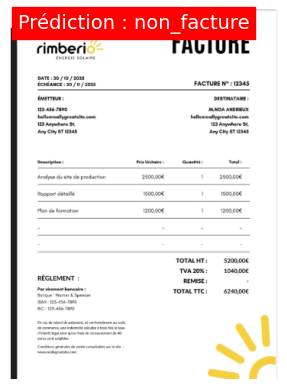

In [ ]:
# ---- Affichage de l'image avec prédiction ----
image_np = np.array(image)
plt.imshow(image_np)
plt.axis('off')
plt.text(10, 25, f'Prédiction : {predicted_class_name}',
         fontsize=14, color='white', backgroundcolor='red')
plt.show()